In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# from google.colab import drive
# drive.flush_and_unmount()
# print('Drive unmounted')

In [5]:
!python --version
!pip --version
# !pip list

Python 3.12.13
pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


## Set up and Import libraries

In [ ]:
!pip install openpyxl # For read excel format. TPU only
!pip install pyvi # For Vietnamese word_segment
!pip install emoji
!pip install gensim
!pip install torch
!pip install transformers==4.52.4

### Library

In [7]:
import pandas as pd
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel, AutoConfig, get_scheduler # AutoModelForSequenceClassification, BertForSequenceClassification
from torch.optim import AdamW
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyvi.ViTokenizer import tokenize  # Vietnamese tokenizer
import emoji
import re
from tqdm import tqdm
import time
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import pickle

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [8]:
# Check GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# # Check for TPU
# try:
#     import torch_xla
#     import torch_xla.core.xla_model as xm
#     device = xm.xla_device()
# except ImportError:
#     # Check for GPU
#     if torch.cuda.is_available():
#         device = torch.device('cuda')
#     # Default to CPU
#     else:
#         device = torch.device('cpu')
print('Device:', device)
# EPOCHS = 6
# N_SPLITS = 10

Device: cuda:0


## Load Data

In [9]:
import os
import pandas as pd
import shutil

repo_root = "/content/drive/MyDrive/ViGoEmotions_Reproduce/ViGoEmotions"

%cd "$repo_root"

print("Current working directory:")
!pwd

print("\nCheck repo root:")
print(os.listdir(repo_root))

print("\nCheck corpus:")
print(os.listdir(os.path.join(repo_root, "corpus")))

print("\nCheck model/docs:")
print(os.listdir(os.path.join(repo_root, "model", "docs")))

# Copy model/docs ra docs để notebook đọc được docs/patterns.json, docs/emojis.json...
docs_src = os.path.join(repo_root, "model", "docs")
docs_dst = os.path.join(repo_root, "docs")

if os.path.exists(docs_dst):
    shutil.rmtree(docs_dst)

shutil.copytree(docs_src, docs_dst)

print("\nCheck root docs after copy:")
print(os.listdir(docs_dst))

# Kiểm tra dataset CSV đọc được không
train_df = pd.read_csv(os.path.join(repo_root, "corpus", "train.csv"))
val_df = pd.read_csv(os.path.join(repo_root, "corpus", "val.csv"))
test_df = pd.read_csv(os.path.join(repo_root, "corpus", "test.csv"))

print("\nDataset shapes:")
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

expected_rows = {"Train": 16531, "Val": 2066, "Test": 2067}
actual_rows = {"Train": len(train_df), "Val": len(val_df), "Test": len(test_df)}
assert actual_rows == expected_rows, f"Unexpected dataset split sizes: {actual_rows}"
print("Verified split row counts:", actual_rows)

print("\nColumns:")
print(train_df.columns)

train_df.head()

/content/drive/MyDrive/ViGoEmotions_Reproduce/ViGoEmotions
Current working directory:
/content/drive/MyDrive/ViGoEmotions_Reproduce/ViGoEmotions

Check repo root:
['README.md', 'annotation', 'corpus', '.git', 'model']

Check corpus:
['label_dict.json', 'test.csv', 'val.csv', 'dataset_V1.xlsx', 'train.csv']

Check model/docs:
['teencode4.txt', 'label_dict.json', 'emojis.json', 'patterns.json']

Check root docs after copy:
['teencode4.txt', 'label_dict.json', 'emojis.json', 'patterns.json']

Dataset shapes:
Train: (16531, 3)
Val: (2066, 3)
Test: (2067, 3)

Columns:
Index(['id', 'text', 'labels'], dtype='object')


,id,text,labels
0,tik000008,Xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,[12]
1,5743,bức ảnh xuất sắc ❤️,"[2, 8, 3]"
2,32895,"Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố là...","[8, 7]"
3,you001182,"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi...",[27]
4,12052,Dima Egiazarov bởi vì chúng tôi là người Việt ...,"[24, 23]"


In [ ]:
# Load normalization dictionaries and inline ASL / emoji-aware model code.
# This notebook is self-contained and does not import from src/.

%cd '/content/drive/MyDrive/ViGoEmotions_Reproduce/ViGoEmotions'
path = '/content/drive/MyDrive/ViGoEmotions_Reproduce/ViGoEmotions'

from dataclasses import dataclass
from urllib.request import urlretrieve
from gensim.models import KeyedVectors

class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=0, clip=0.05, eps=1e-8, reduction='mean'):
        super().__init__()
        if reduction not in {'mean', 'sum', 'none'}:
            raise ValueError(f'Unsupported reduction: {reduction}')
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps
        self.reduction = reduction

    def forward(self, x, y):
        if x.shape != y.shape:
            raise ValueError(f'logits shape {tuple(x.shape)} != targets shape {tuple(y.shape)}')
        y = y.type_as(x)
        p = torch.sigmoid(x)
        p_m = torch.clamp(p - self.clip, min=0.0)
        log_pos = torch.log(torch.clamp(p, min=self.eps))
        log_neg = torch.log(torch.clamp(1.0 - p_m, min=self.eps))
        pos_loss = -y * torch.pow(1.0 - p, self.gamma_pos) * log_pos
        neg_loss = -(1.0 - y) * torch.pow(p_m, self.gamma_neg) * log_neg
        loss = pos_loss + neg_loss
        if self.reduction == 'mean':
            return loss.mean()
        if self.reduction == 'sum':
            return loss.sum()
        return loss


def extract_emojis(text):
    return [ch for ch in str(text) if ch in emoji.EMOJI_DATA]


def load_emoji2vec(path='emoji2vec.bin'):
    return KeyedVectors.load_word2vec_format(str(path), binary=True)


def get_emoji_vector(emojis, e2v, dim=300):
    vectors = []
    for item in emojis:
        if item in e2v:
            vectors.append(np.asarray(e2v[item], dtype=np.float32))
    if not vectors:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(np.stack(vectors, axis=0), axis=0).astype(np.float32)


@dataclass
class EmojiModelOutput:
    logits: torch.Tensor
    pooled_text: torch.Tensor
    pooled_emoji: torch.Tensor


class EmojiAwareViSoBERT(nn.Module):
    def __init__(self, model_name='uitnlp/visobert', num_labels=28, emoji_dim=300, dropout=0.2):
        super().__init__()
        config = AutoConfig.from_pretrained(
            model_name,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1,
        )
        self.bert = AutoModel.from_pretrained(model_name, config=config)
        hidden_size = getattr(config, 'hidden_size', None) or getattr(config, 'dim', None)
        if hidden_size is None:
            raise ValueError(f'Could not infer hidden size from config of {model_name}')
        self.emoji_projection = nn.Sequential(
            nn.Linear(emoji_dim, hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size),
        )
        self.fusion = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_labels),
        )

    def encode_text(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        if outputs.pooler_output is not None:
            return outputs.pooler_output
        return outputs.last_hidden_state[:, 0]

    def forward(self, input_ids, attention_mask, emoji_vectors):
        h_text = self.encode_text(input_ids=input_ids, attention_mask=attention_mask)
        h_emoji = self.emoji_projection(emoji_vectors.float())
        logits = self.fusion(torch.cat([h_text, h_emoji], dim=1))
        return logits


# Load normalization dictionaries
with open(os.path.join(path, 'docs', 'patterns.json'), 'r', encoding='utf-8') as f:
    pattern_dict = json.load(f)
    print(pattern_dict)

with open(os.path.join(path, 'docs', 'emojis.json'), 'r', encoding='utf-8') as f:
    emoji_dict = json.load(f)
    print(emoji_dict)

with open(os.path.join(path, 'docs', 'teencode4.txt'), 'r', encoding='utf-8') as f:
    content = f.read()
    lines = content.split('\n')
    teen_dict = {}
    for line in lines:
        if line.strip():
            elements = line.split('\t')
            if len(elements) >= 2:
                teen_dict.update({elements[0]: elements[1]})
    print(teen_dict)

# Keep a copy of the original text for the Emoji2Vec branch before preprocessing.
for df in [train_df, val_df, test_df]:
    df['original_text'] = df['text'].astype(str)

is_preprocessing = True

print('Using direct CSV splits already loaded from corpus/train.csv, corpus/val.csv, corpus/test.csv')
print('Train shape:', train_df.shape)
print('Val shape:', val_df.shape)
print('Test shape:', test_df.shape)
display(train_df.head())

In [11]:
train_df.info()
val_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16531 entries, 0 to 16530
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      16531 non-null  object
 1   text    16531 non-null  object
 2   labels  16531 non-null  object
dtypes: object(3)
memory usage: 387.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2066 entries, 0 to 2065
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2066 non-null   object
 1   text    2066 non-null   object
 2   labels  2066 non-null   object
dtypes: object(3)
memory usage: 48.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2067 entries, 0 to 2066
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2067 non-null   object
 1   text    2067 non-null   object
 2   labels  2067 non-null   object
dtypes: object(3)
memory usage: 48.6+ KB


In [12]:
# train_df = train_df[:128]
# val_df = val_df[:64]
# test_df = test_df[:64]

### Pre-processing text

In [13]:
text = 'T thích :)))) =))))) =]]]] :>> ==== :::::: ????? !!!!!! thì t cứ :) thôi'
for pattern, replacement in pattern_dict.items():
    text = re.sub(pattern, replacement, text)
print(text)

T thích :)) =)) =]] :> = : ? ! thì t cứ :) thôi


In [ ]:

def normalize_pattern(text):
    """:)))) -> :))"""
    for pattern, replacement in pattern_dict.items():
        text = re.sub(pattern=pattern, repl=replacement, string=text)

    return text


def remove_duplicate_chars(text):
    """Apply for alphabet only. Ex: cườiiiiii -> cười"""
    prev_char = None
    result = []
    for char in text:
        if char.isalpha() and prev_char == char:
            continue
        prev_char = char
        result.append(char)
    return ''.join(result)


def remove_duplicate_emoji(text):
    """😄😄😄😄 -> 😄"""
    result = []
    prev_emoji = None
    for char in text:
        if char in emoji.EMOJI_DATA:
            if char == prev_emoji:
                continue
            prev_emoji = char
        else:
            prev_emoji = None
        result.append(char)
    return ''.join(result)


def replace_teencode(text):
    """
    :param text:
    :return:
    """
    # for teen, normal in teen_dict.items():
    #     text = text.replace(teen, normal)
    # return text
    for old_word, new_word in teen_dict.items():
        pattern = re.compile(r'\b{}\b'.format(re.escape(old_word)))
        text = pattern.sub(new_word, text)
    return text


def replacing_emojis(text):
    for emoji, replacement in emoji_dict.items():
        text = text.replace(emoji, ' ' + replacement + ' ')
    return text


def clean_text(text):
    text = text.lower()
    text = normalize_pattern(text)
    text = remove_duplicate_chars(text)
    text = remove_duplicate_emoji(text)
    text = replace_teencode(text)
    text = replacing_emojis(text)

    # remove new line char '\n'
    text = re.sub(r'(?<![.,!?;:])\n', r'. ', text)  # Replace newline with period and space if no punctuation. (1st priority)
    text = re.sub(r'\n([.,!?;:])?', r' \1', text)  # Replace newline with punctuation if present (2nd step)

    # Add spaces around punctuation marks, except in cases like 'X.Y'. This step must after new line processing.
    punctuation = r'([.,!?;:])'
    # text = re.sub(r'(?<![A-Z])' + punctuation + r'(?![A-Z])', r' \1 ', text) # except patterns like 'X.X.X'
    text = re.sub(punctuation, r' \1 ', text)  # no exceptions

    # remove extra spaces ('\s', '\n', '\t')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print(clean_text(':)))))))'))
print(clean_text('Bao kỉ niệm lại ùa về nguyên vẹn.nhớ quá.... y.ê.u'))


In [ ]:
if is_preprocessing == True:
    for df in [train_df, val_df, test_df]:
        if 'original_text' not in df.columns:
            df['original_text'] = df['text'].astype(str)
    train_df['clean_text'] = train_df['text'].apply(clean_text)
    val_df['clean_text'] = val_df['text'].apply(clean_text)
    test_df['clean_text'] = test_df['text'].apply(clean_text)
    display(train_df.head())

In [16]:
# Relace 'text' col by 'clean_text' col
if is_preprocessing == True:
    for df in [train_df, val_df, test_df]:
        if  'text' in df.columns and 'clean_text' in df.columns:
            df['text'] = df['clean_text']
            df.drop(columns=['clean_text'], inplace=True, errors='ignore') # ignore if 'clean_text' does not exist
    display(train_df)

,id,text,labels
0,tik000008,xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,[12]
1,5743,bức ảnh xuất sắc ❤️,"[2, 8, 3]"
2,32895,"vừa đẹp trai , vừa tài giỏi . nhà mặt phố , bố...","[8, 7]"
3,you001182,"bài học : . 1 : 5 nhìn , 4 chạm , 3 nghe , 2 n...",[27]
4,12052,dima egiazarov bởi vì chúng tôi là người việt ...,"[24, 23]"
...,...,...,...
16526,768,tự dưng cay mẹ mắt,[21]
16527,1983,per đã nhẫn nhịn lắm . . . đến khi con sen tao...,"[0, 10, 2]"
16528,18199,"trời ơi , xem tin hôm qua giờ mà không biết là...","[13, 21, 6]"
16529,tik011747,nếu có thể quay lại tôi thề ngày hôm ấy tôi sẽ...,"[18, 4]"


In [ ]:
# Cleaned splits remain in memory for this experiment.
# Do not export or reload an Excel dataset; train/val/test come directly from the provided CSV files.
print('Cleaned CSV splits kept in memory; original_text preserved for the emoji branch.')

In [18]:
train_texts = train_df['text'].tolist()
train_labels = train_df['labels'].tolist()
print(train_texts[0])
print(train_labels[0])

xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
[12]


### Encode label

In [19]:
# Load label dict
with open(os.path.join(path, 'docs/label_dict.json'), 'r') as f:
    label_dict = json.load(f)

print("Number of labels:", len(label_dict))
print(label_dict)

Number of labels: 28
{'0': 'amusement', '1': 'excitement', '2': 'joy', '3': 'love', '4': 'desire', '5': 'optimism', '6': 'caring', '7': 'pride', '8': 'admiration', '9': 'gratitude', '10': 'relief', '11': 'approval', '12': 'realization', '13': 'surprise', '14': 'curiosity', '15': 'confusion', '16': 'fear', '17': 'nervousness', '18': 'remorse', '19': 'embarrassment', '20': 'disappointment', '21': 'sadness', '22': 'grief', '23': 'disgust', '24': 'anger', '25': 'annoyance', '26': 'disapproval', '27': 'neutral'}


In [20]:
label_to_idx = {label:int(idx) for idx, label in label_dict.items()}
idx_to_label = {int(idx):label for idx, label in label_dict.items()}
print(label_to_idx)
print(idx_to_label)

{'amusement': 0, 'excitement': 1, 'joy': 2, 'love': 3, 'desire': 4, 'optimism': 5, 'caring': 6, 'pride': 7, 'admiration': 8, 'gratitude': 9, 'relief': 10, 'approval': 11, 'realization': 12, 'surprise': 13, 'curiosity': 14, 'confusion': 15, 'fear': 16, 'nervousness': 17, 'remorse': 18, 'embarrassment': 19, 'disappointment': 20, 'sadness': 21, 'grief': 22, 'disgust': 23, 'anger': 24, 'annoyance': 25, 'disapproval': 26, 'neutral': 27}
{0: 'amusement', 1: 'excitement', 2: 'joy', 3: 'love', 4: 'desire', 5: 'optimism', 6: 'caring', 7: 'pride', 8: 'admiration', 9: 'gratitude', 10: 'relief', 11: 'approval', 12: 'realization', 13: 'surprise', 14: 'curiosity', 15: 'confusion', 16: 'fear', 17: 'nervousness', 18: 'remorse', 19: 'embarrassment', 20: 'disappointment', 21: 'sadness', 22: 'grief', 23: 'disgust', 24: 'anger', 25: 'annoyance', 26: 'disapproval', 27: 'neutral'}


In [21]:

def encode_labels(label, label_dict, num_classes=28, mode=None):
    """Converts a label string to a numerical representation.

    This function takes a label string and converts it into either a one-hot encoded vector or a list of label indices,
    depending on the specified mode.

    Args:
        label (str): The label string to encode. It can be a comma-separated string of numeric labels
                     (e.g., "[13, 20, 21, 0]") or a comma-separated string of string labels
                     (e.g., '["amusement", "desire", "embarrassment"]').
        label_dict (dict): A dictionary mapping label names (strings) to their corresponding indices (integers).
        num_classes (int, optional): The total number of classes. Defaults to 28.
        mode (str, optional): The encoding mode. Can be 'label' for label indices or 'one-hot' for one-hot encoding.
                              Defaults to 'one-hot'.

    Returns:
        np.ndarray or list: The encoded label representation. If `mode` is 'one-hot', it returns a one-hot encoded vector
                            as a NumPy array. If `mode` is 'label', it returns a list of label indices.

    Examples:
        >>> encode_labels("[13, 20, 21, 0]", idx_to_label)
        array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0])
        >>> encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx)
        array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
        >>> encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx, mode='label')
        [0, 13, 20]
    """
    labels = label.replace('[', '').replace(']', '').replace("'", '').replace('"', '').split(',')
    labels = [label.strip() for label in labels]
    # print(labels)
    if mode is None or mode == 'one-hot':
        label_vector = np.zeros(len(label_dict), dtype=int) # default: float64
        if labels[0].isnumeric(): # If input list is numeric labels
            labels = [int(label) for label in labels]
            for idx in label_dict.values():
                if idx in labels:
                    label_vector[idx] = 1
        elif not labels[0].isnumeric(): # If input list is string labels
            for label, idx in label_dict.items():
                if label in labels:
                    label_vector[idx] = 1
        return label_vector
    elif mode == 'label':
        labels = [label_dict[label] for label in labels]
        return labels



print('Ex1:', encode_labels("[13, 20, 21, 0]", label_to_idx))
print('Ex2:', encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx))
print('Ex3:', encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx, mode='label'))

Ex1: [1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
Ex2: [1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
Ex3: [0, 4, 19]


In [ ]:
# Create train-val-test with one-hot encoding for labels.
# text = preprocessed text for ViSoBERT; original_text = raw text for emoji extraction.
train_texts = train_df['text'].tolist()
train_original_texts = train_df['original_text'].tolist()
train_labels = train_df['labels'].tolist()
train_labels = [encode_labels(label, label_to_idx) for label in train_labels]
print(train_texts[0])
print(train_original_texts[0])
print(train_labels[0])

val_texts = val_df['text'].tolist()
val_original_texts = val_df['original_text'].tolist()
val_labels = val_df['labels'].tolist()
val_labels = [encode_labels(label, label_to_idx) for label in val_labels]
print(val_texts[0])
print(val_original_texts[0])
print(val_labels[0])

test_texts = test_df['text'].tolist()
test_original_texts = test_df['original_text'].tolist()
test_labels = test_df['labels'].tolist()
test_labels = [encode_labels(label, label_to_idx) for label in test_labels]
print(test_texts[0])
print(test_original_texts[0])
print(test_labels[0])

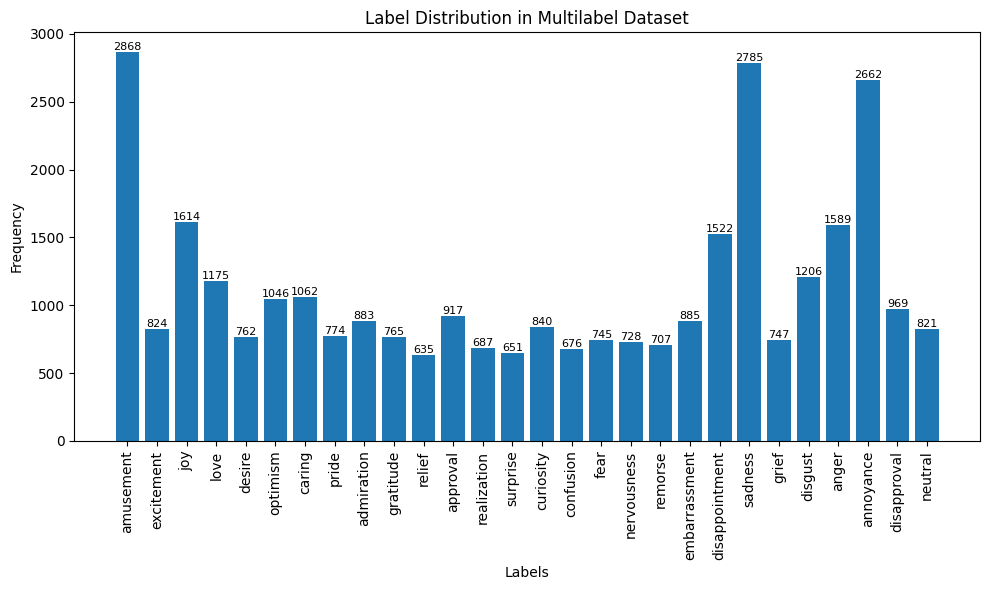

In [23]:
label_frequencies = np.sum(train_labels, axis=0) # calculate the frequency per label
label_names = list(label_dict.values())

plt.figure(figsize=(10, 6))
plt.bar(x=label_names, height=label_frequencies)
for x, y in zip(label_names, label_frequencies):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8)

plt.xlabel('Labels')
plt.ylabel('Frequency')
plt.title('Label Distribution in Multilabel Dataset')
plt.xticks(rotation=90) # Rotate x-axis labels for readibility
plt.tight_layout() # adjust layout to prevent labels from overlapping
plt.show()

## DataLoader

In [24]:
# Select model to deploy
model_type = 'viso' # {'viso': 'visobert', 'pho': 'phobert-base-v2}

In [25]:
if model_type == 'pho':
    print('Create tokenizer for PhoBERT')
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2", use_fast=False)
elif model_type == 'viso':
    print('Create tokenizer for visoBERT')
    tokenizer = AutoTokenizer.from_pretrained("uitnlp/visobert", use_fast=False)
elif model_type == 'cafe':
    print('Create tokenizer for cafeBERT')
    tokenizer = AutoTokenizer.from_pretrained('uitnlp/CafeBERT')
elif model_type == 'vi':
    print('Create tokenizer for viBERT')
    tokenizer = AutoTokenizer.from_pretrained('FPTAI/vibert-base-cased')

tokenizer

Create tokenizer for visoBERT


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/471k [00:00<?, ?B/s]

XLMRobertaTokenizer(name_or_path='uitnlp/visobert', vocab_size=15002, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	15001: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

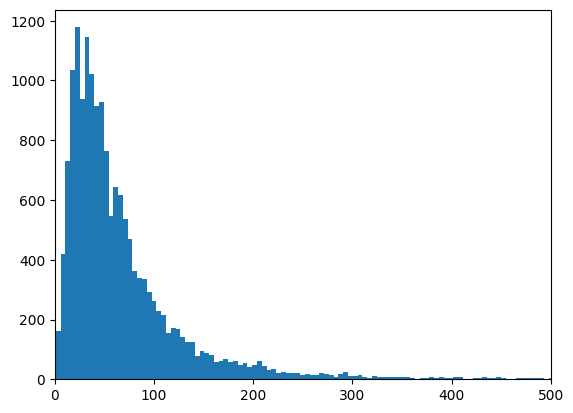

In [26]:
# vẽ biểu đồ thể hiện phân bố chiều dài của câu trong tập dữ liệu.
import matplotlib.pyplot as plt

plt.hist([len(s) for s in train_texts], bins=192)
plt.xlim(0, 500)
plt.show()

In [27]:
max_len = 200 # max_len should cover at least 95% texts
print(len([t for t in train_texts if len(t) <= max_len]) / len(train_texts))

0.9548726634807332


In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128, original_texts=None,
                 e2v=None, include_emoji_vectors=False, emoji_dim=300):
        self.texts = [str(text) for text in texts]
        self.original_texts = [str(text) for text in (original_texts if original_texts is not None else texts)]
        self.labels = torch.tensor(labels, dtype=torch.float)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.e2v = e2v
        self.include_emoji_vectors = include_emoji_vectors
        self.emoji_dim = emoji_dim

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        text = tokenize(text)
        original_text = self.original_texts[idx]

        # ViSoBERT/XLM-R tokenizer should be called directly, not via encode_plus.
        encoding = self.tokenizer(
            text,
            truncation=True,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_attention_mask=True,
            return_token_type_ids=False,
            return_tensors='pt'
        )

        item = {
            'text': text,
            'original_text': original_text,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'targets': self.labels[idx]
        }

        if self.include_emoji_vectors:
            emoji_items = extract_emojis(original_text)
            emoji_vector = get_emoji_vector(emoji_items, self.e2v, dim=self.emoji_dim)
            item['emoji_vectors'] = torch.tensor(emoji_vector, dtype=torch.float)

        return item


# ASL-only datasets do not include emoji vectors.
train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, max_len=max_len, original_texts=train_original_texts)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer, max_len=max_len, original_texts=val_original_texts)
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer, max_len=max_len, original_texts=test_original_texts)

with open(f'corpus/dataset_{model_type}bert.pkl', 'wb') as f:
    pickle.dump((train_dataset, val_dataset, test_dataset), f)

In [31]:
train_dataset[5]

{'text': 'giờ mới biết',
 'input_ids': tensor([  0, 321,   9,  54,  14, 152,   2,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1, 

In [32]:
for i in range(0, 10):
    print(train_dataset[i]['text'])

xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
bức ảnh xuất sắc ❤️
vừa đẹp trai , vừa tài giỏi . nhà mặt phố , bố làm to
bài học : . 1 : 5 nhìn , 4 chạm , 3 nghe , 2 ngửi , 1 nếm . 2 : tư duy 3% . 3 : phương pháp thở
dima egiazarov bởi vì chúng tôi là người việt nam , còn hiểu hay không thì kệ mẹ bạn
giờ mới biết
cảmày thấy tự hào về đấtao nướchị mình
nhìn mặt là cười phọt rồi
cris minh algeria nó theo đạo hồi . không được chuyển giới . nhiều người là nữ nhưng vẫn tiết nhiều tetosteron hơn bình thường . cơ bắp sẽ phát triển mạnh hơn
nó giống tao ghê . gặp tao tao cũng chọn mày


In [33]:
# Iterate through the dataset to view the mappings for a specific sample
for idx in range(1):  # Adjust range to view more samples
    sample = train_dataset[idx]  # Get one sample
    input_ids = sample['input_ids']  # Extract input_ids
    tokens = tokenizer.convert_ids_to_tokens(input_ids.tolist())  # Convert IDs to tokens

    print(f"Original Text: {sample['text']}")
    print(f"Input IDs: {input_ids.tolist()}")
    print(f"Tokens: {tokens}")
    print(f"Labels: {sample['targets'].tolist()}")
    print("\nIndex-Token Mapping:")
    for i, token in enumerate(tokens):
        print(f"Index {i}: \tToken {token}")


Original Text: xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
Input IDs: [0, 34, 157, 50, 23, 3643, 10, 63, 286, 468, 8, 52, 14, 169, 12, 91, 309, 197, 26, 99, 297, 18, 167, 594, 309, 24, 80, 5, 93, 237, 816, 1496, 1700, 237, 5, 119, 9, 405, 26, 68, 10, 295, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Tokens: ['<s>', '▁x', 'em', '▁mà', '▁ng', 'ẫm', '▁l', 'ại', '▁cu', 'ộc', '▁đ', 'ời', '▁b', 'ản', '▁th', 'ân', '▁ta', '▁đã', '▁tr', 'ải', '▁qua', '▁nh', 'iều', '▁thứ', '▁ta', '▁r', 'ồi', '▁c', 'ũng', '▁sẽ', '

In [34]:
# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2) # num_workers=2: Sử dụng 2 tiến trình để tải dữ liệu song song -> cải thiện tốc độ nạp dữ liệu
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
train_loader.__init__

<bound method DataLoader.__init__ of <torch.utils.data.dataloader.DataLoader object at 0x7e0dfaef0b90>>

## Model

In [35]:

# Load tokenizer và model
class ModelSentimentClassifier(nn.Module):
    def __init__(self, n_classes, model_type='pho'):
        super(ModelSentimentClassifier, self).__init__()
        # Select BERT model
        if model_type == 'pho':
            bert_model = 'vinai/phobert-base-v2'
        elif model_type == 'viso':
            bert_model = 'uitnlp/visobert'
        elif model_type == 'cafe':
            bert_model = 'uitnlp/CafeBERT'
        elif model_type == 'vi':
            bert_model = 'FPTAI/vibert-base-cased'

        # Load config with custom dropout settings
        config = AutoConfig.from_pretrained(
            bert_model,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1
        )

        # Download BERT
        self.bert = AutoModel.from_pretrained(bert_model, config=config)
        self.drop = nn.Dropout(p=0.2)
        self.fc = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        last_hidden_state, output = self.bert(
            input_ids = input_ids,
            attention_mask = attention_mask,
            return_dict = False # Dropout sẽ báo lỗi nếu không có điều này
        )

        x = self.drop(output)
        x = self.fc(x)
        return {'logits': x} # add more if needed

model = ModelSentimentClassifier(n_classes=len(label_dict), model_type=model_type).to(device)
model

# model_bert = "uitnlp/visobert"
# tokenizer = AutoTokenizer.from_pretrained(model_bert, use_fast=False) # https://huggingface.co/uitnlp/visobert
# model = AutoModelForSequenceClassification.from_pretrained(model_bert, num_labels=28) # AutoModelForSequenceClassification, model Bert thêm 2 layers Dense và Dropout với droprate = 0.1.
# model.to(device) # Move model to GPU if GPU is available

pytorch_model.bin:   0%|          | 0.00/390M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/390M [00:00<?, ?B/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ModelSentimentClassifier(
  (bert): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(15004, 768, padding_idx=1)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
   

In [36]:
# Hàm để tính toán số lượng tham số và phân loại chúng
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params

    # In ra các lớp và tham số trainable/non-trainable
    print(f"\n--- Trainable vs Non-trainable Parameters ---")
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"Trainable: {name} ({param.numel()} parameters)")
        else:
            print(f"Non-trainable: {name} ({param.numel()} parameters)")

    return total_params, trainable_params, non_trainable_params

# Tính toán và hiển thị kết quả
total_params, trainable_params, non_trainable_params = count_parameters(model)
print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")


--- Trainable vs Non-trainable Parameters ---
Trainable: bert.embeddings.word_embeddings.weight (11523072 parameters)
Trainable: bert.embeddings.token_type_embeddings.weight (1536 parameters)
Trainable: bert.embeddings.LayerNorm.weight (768 parameters)
Trainable: bert.embeddings.LayerNorm.bias (768 parameters)
Trainable: bert.embeddings.position_embeddings.weight (394752 parameters)
Trainable: bert.encoder.layer.0.attention.self.query.weight (589824 parameters)
Trainable: bert.encoder.layer.0.attention.self.query.bias (768 parameters)
Trainable: bert.encoder.layer.0.attention.self.key.weight (589824 parameters)
Trainable: bert.encoder.layer.0.attention.self.key.bias (768 parameters)
Trainable: bert.encoder.layer.0.attention.self.value.weight (589824 parameters)
Trainable: bert.encoder.layer.0.attention.self.value.bias (768 parameters)
Trainable: bert.encoder.layer.0.attention.output.dense.weight (589824 parameters)
Trainable: bert.encoder.layer.0.attention.output.dense.bias (768 param

In [37]:
EPOCHS = 12
optimizer = AdamW(model.parameters(), lr=5e-5)

# Learning rate will gradually increase for the 1st epochs (warmup phase) and then linearly decrease until the end of training to be almost zero.
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=len(train_loader), num_training_steps=len(train_loader)*EPOCHS)

## Train and Test

In [ ]:
# Loss function: Asymmetric Loss for multi-label classification.
# ASL works directly on logits; pos_weight from BCE is no longer used.
loss_fn = AsymmetricLoss(gamma_neg=4, gamma_pos=0, clip=0.05).to(device)
print(loss_fn)

In [ ]:
def get_logits(model, data, device='cpu'):
    input_ids = data['input_ids'].to(device)
    attention_mask = data['attention_mask'].to(device)
    if 'emoji_vectors' in data:
        emoji_vectors = data['emoji_vectors'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, emoji_vectors=emoji_vectors)
    else:
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    if isinstance(outputs, dict):
        return outputs['logits']
    return outputs


def train(model, data_loader, loss_fn, optimizer, device='cpu', threshold=0.5):
    model.train()
    losses = []
    all_targets = []
    all_preds = []

    for data in data_loader:
        targets = data['targets'].to(device)

        optimizer.zero_grad()
        logits = get_logits(model, data, device=device)

        loss = loss_fn(logits, targets)
        losses.append(loss.item())

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        lr_scheduler.step()

        preds = torch.sigmoid(logits)
        preds = (preds >= threshold).int()

        all_targets.append(targets.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)

    mean_loss = np.mean(losses)
    correct_per_label = (all_targets == all_preds).sum(axis=0)
    total_per_label = all_targets.shape[0]
    label_accuracies = correct_per_label / total_per_label
    average_accuracy = label_accuracies.mean()
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

    print(f'Train Loss: {mean_loss:.4f} | Average Accuracy: {average_accuracy:.4f} | Macro F1: {macro_f1:.4f}')
    return mean_loss, average_accuracy, macro_f1

In [ ]:
def eval(model, data_loader, loss_fn, device='cpu', threshold=0.5):
    model.eval()
    losses = []
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for data in data_loader:
            targets = data['targets'].to(device)
            logits = get_logits(model, data, device=device)

            loss = loss_fn(logits, targets)
            losses.append(loss.item())

            preds = torch.sigmoid(logits)
            preds = (preds >= threshold).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)

    mean_loss = np.mean(losses)
    correct_per_label = (all_targets == all_preds).sum(axis=0)
    total_per_label = all_targets.shape[0]
    label_accuracies = correct_per_label / total_per_label
    average_accuracy = label_accuracies.mean()
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

    print(f'Validation Loss: {mean_loss:.4f} | Average Accuracy: {average_accuracy:.4f} | Macro F1: {macro_f1:.4f}')
    return mean_loss, average_accuracy, macro_f1

In [ ]:
def test(model, data_loader, device='cpu', threshold=0.5):
    model.to(device)
    model.eval()
    texts, original_texts, predict_probs, predicts, real_values = [], [], [], [], []

    with torch.no_grad():
        for data in data_loader:
            targets = data['targets'].to(device)
            logits = get_logits(model, data, device=device)

            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).int()

            texts.extend(data['text'])
            original_texts.extend(data.get('original_text', data['text']))
            predicts.extend(preds.cpu().numpy())
            predict_probs.extend(probs.cpu().numpy())
            real_values.extend(targets.cpu().numpy())

    predicts = torch.tensor(np.asarray(predicts))
    predict_probs = torch.tensor(np.asarray(predict_probs))
    real_values = torch.tensor(np.asarray(real_values))

    return predict_probs, predicts, real_values

In [43]:
import os

%cd '/content/drive/MyDrive/ViGoEmotions_Reproduce/ViGoEmotions'

os.makedirs('saved_models', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

print("saved_models and checkpoints folders ready")
!ls

/content/drive/MyDrive/ViGoEmotions_Reproduce/ViGoEmotions
saved_models folder ready
annotation  corpus  docs  model  README.md  saved_models


In [ ]:
all_train_losses = []
all_train_accuracies = []
all_train_f1 = []
all_val_losses = []
all_val_accuracies = []
all_val_f1 = []
best_f1 = 0
best_epoch = 0
checkpoint_path = 'checkpoints/asl_visobert_seed42.pth'

os.makedirs('checkpoints', exist_ok=True)

# ASL-only training loop
start_time = time.time()
for epoch in tqdm(range(EPOCHS), desc='ASL epoch'):
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{EPOCHS}, Learning Rate: {current_lr}")
    train_loss, train_acc, train_f1 = train(model, train_loader, loss_fn, optimizer, device)
    all_train_losses.append(train_loss)
    all_train_accuracies.append(train_acc)
    all_train_f1.append(train_f1)

    val_loss, val_acc, val_f1 = eval(model, val_loader, loss_fn, device)
    all_val_losses.append(val_loss)
    all_val_accuracies.append(val_acc)
    all_val_f1.append(val_f1)

    if val_f1 > best_f1:
        print('Saving the ASL model....')
        torch.save(model, checkpoint_path)
        best_f1 = val_f1
        best_epoch = epoch + 1

    time.sleep(1)

asl_val_f1_table = pd.DataFrame({
    'epoch': list(range(1, len(all_val_f1) + 1)),
    'val_macro_f1': all_val_f1,
})
print(f'ASL completed! {(time.time() - start_time):.2f} seconds')
display(asl_val_f1_table)

In [46]:
import os

%cd '/content/drive/MyDrive/ViGoEmotions_Reproduce/ViGoEmotions'

os.makedirs('reports', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('saved_models', exist_ok=True)

print("Folders ready:")
!ls

/content/drive/MyDrive/ViGoEmotions_Reproduce/ViGoEmotions
Folders ready:
annotation  corpus  docs  model  README.md  reports  saved_models


In [ ]:
# Save ASL metrics
metrics = {
    'train_loss': all_train_losses,
    'train_acc': all_train_accuracies,
    'train_f1': all_train_f1,
    'val_loss': all_val_losses,
    'val_acc': all_val_accuracies,
    'val_f1': all_val_f1,
}

os.makedirs('reports', exist_ok=True)
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv('reports/asl_metrics.csv', index=False)
display(metrics_df)

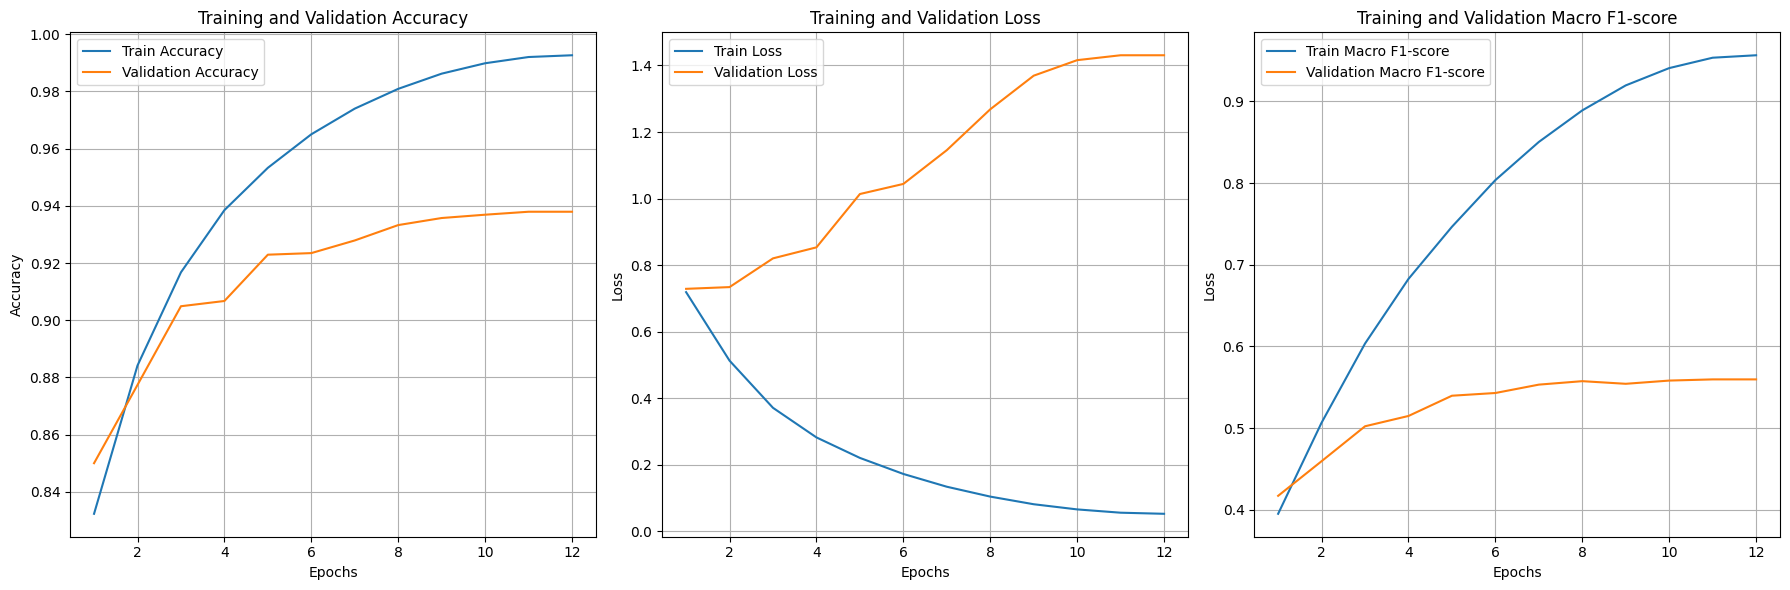

In [48]:
def plot_accu_loss(all_train_accuracies, all_train_losses, all_train_f1, all_val_accuracies, all_val_losses, all_val_f1):
    epochs = range(1, len(all_train_losses) + 1)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, all_train_accuracies, label='Train Accuracy')
    plt.plot(epochs, all_val_accuracies, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()


    plt.subplot(1, 3, 2)
    plt.plot(epochs, all_train_losses, label='Train Loss')
    plt.plot(epochs, all_val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()


    plt.subplot(1, 3, 3)
    plt.plot(epochs, all_train_f1, label='Train Macro F1-score')
    plt.plot(epochs, all_val_f1, label='Validation Macro F1-score')
    plt.title('Training and Validation Macro F1-score')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_accu_loss(all_train_accuracies, all_train_losses, all_train_f1, all_val_accuracies, all_val_losses, all_val_f1)

### Evaluation

In [ ]:
model = torch.load('checkpoints/asl_visobert_seed42.pth', weights_only=False)
predict_probs, predicts, real_values = test(model, test_loader, device)

In [ ]:
def save_classification_outputs(real_values, predicts, report_path, title):
    labels = list(label_dict.values())
    report = classification_report(
        real_values,
        predicts,
        target_names=labels,
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report).transpose()
    report_df.index.name = 'class'
    report_df.to_csv(report_path)

    test_macro_f1 = f1_score(real_values, predicts, average='macro', zero_division=0)
    per_class_f1 = report_df.loc[labels, 'f1-score']

    print(title)
    print(classification_report(real_values, predicts, target_names=labels, zero_division=0))
    print('Test Macro F1:', test_macro_f1)
    print('Per-class F1:')
    display(per_class_f1.reset_index().rename(columns={'class': 'label', 'f1-score': 'f1'}))
    return report_df, test_macro_f1

os.makedirs('reports', exist_ok=True)
asl_report_df, asl_test_macro_f1 = save_classification_outputs(
    real_values,
    predicts,
    'reports/asl_classification_report.csv',
    'ASL-only ViSoBERT classification report',
)

In [ ]:
# Emoji-aware ViSoBERT + ASL experiment
from urllib.request import urlretrieve

emoji2vec_path = 'emoji2vec.bin'
emoji2vec_url = 'https://raw.githubusercontent.com/uclnlp/emoji2vec/master/pre-trained/emoji2vec.bin'
if not os.path.exists(emoji2vec_path):
    print('Downloading Emoji2Vec embeddings...')
    urlretrieve(emoji2vec_url, emoji2vec_path)

print('Loading Emoji2Vec embeddings...')
e2v = load_emoji2vec(emoji2vec_path)

emoji_train_dataset = SentimentDataset(
    train_texts, train_labels, tokenizer, max_len=max_len,
    original_texts=train_original_texts, e2v=e2v, include_emoji_vectors=True,
)
emoji_val_dataset = SentimentDataset(
    val_texts, val_labels, tokenizer, max_len=max_len,
    original_texts=val_original_texts, e2v=e2v, include_emoji_vectors=True,
)
emoji_test_dataset = SentimentDataset(
    test_texts, test_labels, tokenizer, max_len=max_len,
    original_texts=test_original_texts, e2v=e2v, include_emoji_vectors=True,
)

emoji_train_loader = DataLoader(emoji_train_dataset, batch_size=32, shuffle=True, num_workers=2)
emoji_val_loader = DataLoader(emoji_val_dataset, batch_size=32, shuffle=False, num_workers=2)
emoji_test_loader = DataLoader(emoji_test_dataset, batch_size=32, shuffle=False, num_workers=2)

set_seed(42)
emoji_model = EmojiAwareViSoBERT(
    model_name='uitnlp/visobert',
    num_labels=len(label_dict),
    emoji_dim=300,
    dropout=0.2,
).to(device)
emoji_loss_fn = AsymmetricLoss(gamma_neg=4, gamma_pos=0, clip=0.05).to(device)
optimizer = AdamW(emoji_model.parameters(), lr=5e-5)
lr_scheduler = get_scheduler(
    'linear',
    optimizer=optimizer,
    num_warmup_steps=len(emoji_train_loader),
    num_training_steps=len(emoji_train_loader) * EPOCHS,
)

emoji_all_train_losses = []
emoji_all_train_accuracies = []
emoji_all_train_f1 = []
emoji_all_val_losses = []
emoji_all_val_accuracies = []
emoji_all_val_f1 = []
emoji_best_f1 = 0
emoji_best_epoch = 0
emoji_checkpoint_path = 'checkpoints/emoji_asl_visobert_seed42.pth'

start_time = time.time()
for epoch in tqdm(range(EPOCHS), desc='Emoji ASL epoch'):
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{EPOCHS}, Learning Rate: {current_lr}")
    train_loss, train_acc, train_f1 = train(emoji_model, emoji_train_loader, emoji_loss_fn, optimizer, device)
    emoji_all_train_losses.append(train_loss)
    emoji_all_train_accuracies.append(train_acc)
    emoji_all_train_f1.append(train_f1)

    val_loss, val_acc, val_f1 = eval(emoji_model, emoji_val_loader, emoji_loss_fn, device)
    emoji_all_val_losses.append(val_loss)
    emoji_all_val_accuracies.append(val_acc)
    emoji_all_val_f1.append(val_f1)

    if val_f1 > emoji_best_f1:
        print('Saving the emoji-aware ASL model....')
        torch.save(emoji_model, emoji_checkpoint_path)
        emoji_best_f1 = val_f1
        emoji_best_epoch = epoch + 1

    time.sleep(1)

emoji_val_f1_table = pd.DataFrame({
    'epoch': list(range(1, len(emoji_all_val_f1) + 1)),
    'val_macro_f1': emoji_all_val_f1,
})
print(f'Emoji-aware ASL completed! {(time.time() - start_time):.2f} seconds')
display(emoji_val_f1_table)

emoji_metrics_df = pd.DataFrame({
    'train_loss': emoji_all_train_losses,
    'train_acc': emoji_all_train_accuracies,
    'train_f1': emoji_all_train_f1,
    'val_loss': emoji_all_val_losses,
    'val_acc': emoji_all_val_accuracies,
    'val_f1': emoji_all_val_f1,
})
emoji_metrics_df.to_csv('reports/emoji_asl_metrics.csv', index=False)

emoji_model = torch.load(emoji_checkpoint_path, weights_only=False)
emoji_predict_probs, emoji_predicts, emoji_real_values = test(emoji_model, emoji_test_loader, device)
emoji_report_df, emoji_test_macro_f1 = save_classification_outputs(
    emoji_real_values,
    emoji_predicts,
    'reports/emoji_asl_classification_report.csv',
    'Emoji-aware ASL ViSoBERT classification report',
)

baseline_report_path = 'reports/baseline_classification_report.csv'
if os.path.exists(baseline_report_path):
    labels = list(label_dict.values())
    baseline_report_df = pd.read_csv(baseline_report_path, index_col=0)
    baseline_f1_col = 'f1-score' if 'f1-score' in baseline_report_df.columns else 'f1'
    delta_df = pd.DataFrame({
        'baseline_f1': baseline_report_df.loc[labels, baseline_f1_col].astype(float),
        'asl_f1': asl_report_df.loc[labels, 'f1-score'].astype(float),
        'emoji_asl_f1': emoji_report_df.loc[labels, 'f1-score'].astype(float),
    })
    delta_df['asl_f1_delta'] = delta_df['asl_f1'] - delta_df['baseline_f1']
    delta_df['emoji_asl_f1_delta'] = delta_df['emoji_asl_f1'] - delta_df['baseline_f1']
    delta_df.index.name = 'class'
    print('Per-class F1 delta vs baseline:')
    display(delta_df.sort_values('emoji_asl_f1_delta'))
else:
    print(f'WARNING: {baseline_report_path} not found; skipping per-class F1 delta vs baseline.')

In [51]:
def check_wrong(real_values, predicts):
    wrong_arr = []
    wrong_labels = []
    for i in range(len(predicts)):
        # So sánh element-wise và kiểm tra sự khác biệt
        if not np.array_equal(predicts[i], real_values[i]):
            wrong_arr.append(i)
            wrong_labels.append(predicts[i])  # Lưu toàn bộ vector nhãn dự đoán
    return wrong_arr, wrong_labels

# Gọi hàm check_wrong
wrong_arr, wrong_labels = check_wrong(real_values, predicts)

class_names = list(label_dict.values())

print(f'Wrong predicted using {model_type}bert')
for i in range(10):
    print('-'*50)
    idx = wrong_arr[i]
    wrong_pred = wrong_labels[i]
    real_label = real_values[idx]
    predicted_labels = [class_names[j] for j in range(len(wrong_pred)) if wrong_pred[j] == 1]
    real_labels = [class_names[j] for j in range(len(real_label)) if real_label[j] == 1]

    print(f"Sentence: {test_df.iloc[idx].text}")
    print(f"Predicted: {predicted_labels} --vs-- Real label: {real_labels}")

Wrong predicted using visobert
--------------------------------------------------
Sentence: không coi p1 đi xem p2 thì được không ta mai huệ
Predicted: ['curiosity', 'confusion'] --vs-- Real label: ['curiosity']
--------------------------------------------------
Sentence: lại bộ sách kết nối với cuộc sống . . . !
Predicted: ['disappointment', 'annoyance'] --vs-- Real label: ['disappointment']
--------------------------------------------------
Sentence: có ai ngu như tao không đơn phương con nhỏ cạnh nhà 4 năm mặc dù nó ngồi chung bàn với tao suốt mấy năm cấp 3 : ((
Predicted: ['remorse', 'disappointment', 'sadness'] --vs-- Real label: ['embarrassment', 'disappointment', 'sadness']
--------------------------------------------------
Sentence: về nhan sắc , khó có thể có quy định cụ thể lắm bạn . tiêu chuẩn cái đẹp của 20 năm trước và giờ cũng khác nhau . chỉ cần ưa nhìn trong mắt mình thì có thể được coi là đẹp rồi . kể cả trong cùng 1 thời điểm , nhiều idol đẹp trong mắt người này nhưng

In [ ]:
print('ASL-only best validation Macro F1:', max(all_val_f1))
print('ASL-only best epoch:', best_epoch)
print('ASL-only test Macro F1:', asl_test_macro_f1)
print('ASL-only checkpoint:', 'checkpoints/asl_visobert_seed42.pth')
print('ASL-only report:', 'reports/asl_classification_report.csv')
print('ASL-only validation Macro F1 per epoch:')
display(asl_val_f1_table)

if 'emoji_all_val_f1' in globals():
    print('Emoji-aware ASL best validation Macro F1:', max(emoji_all_val_f1))
    print('Emoji-aware ASL best epoch:', emoji_best_epoch)
    print('Emoji-aware ASL test Macro F1:', emoji_test_macro_f1)
    print('Emoji-aware ASL checkpoint:', 'checkpoints/emoji_asl_visobert_seed42.pth')
    print('Emoji-aware ASL report:', 'reports/emoji_asl_classification_report.csv')
    print('Emoji-aware ASL validation Macro F1 per epoch:')
    display(emoji_val_f1_table)

print('Checkpoint files:')
!ls checkpoints

print('Reports:')
!ls reports